In [2]:
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
# root_proj = Path("/Users/yk/Documents/Projects/Pre-PhD")
# root_proj = Path("/Users/VERTPOM-UPJV/Documents/Banque_de_l'energie_V2/Data_prediction_K/Pre-PhD")
root_proj = Path("/Users/alesk/Documents/Git-repo/Pre-PhD")
# root_proj = Path("D:/GIT-REPO/Pre-PhD")
if str(root_proj/"src") not in sys.path:
    sys.path.append(str(root_proj/"src"))

In [40]:
import pandas as pd
year = "2023"
df = pd.read_excel(root_proj / "DATA_SYSTEM_LIDL" / "Raw_chargelogs" / f"Chargelogs {year}.xlsx")
df 

,Id,Start,End,MeterStart,MeterEnd,DurationTotal,MeterTotal,EVSEId,ChargePointLabel,RateSlug,TotalCosts,CostTotalGross,TotalAmountDuration,TotalAmountPower,TotalAmountOfLocalCurrency,CardId,EMPName
0,44950385,2023-01-01 12:57:34,2023-01-01 14:06:52,0,8070,4158,8070,FR*LDL*E00000149,LFR3591EVCP05,INTERN_550_COM186,1.530,1.530,0,1.530,1.530,Roaming,Chargemap SAS
1,44930833,2023-01-01 00:55:15,2023-01-01 19:47:40,0,31848,67945,31848,FR*LDL*E00000147,LFR3591EVCP04,INTERN_550_COM186,6.038,6.038,0,6.038,6.038,Roaming,IZIVIA
2,44991186,2023-01-02 07:01:55,2023-01-02 07:35:46,0,3910,2031,3910,FR*LDL*E00000150,LFR3591EVCP05,INTERN_550_COM186,0.741,0.741,0,0.741,0.741,Roaming,Chargemap SAS
3,44998697,2023-01-02 08:49:00,2023-01-02 09:08:30,0,2207,1170,2207,FR*LDL*E00000147,LFR3591EVCP04,INTERN_550_COM186,0.418,0.418,0,0.418,0.418,Roaming,Chargemap SAS
4,45050871,2023-01-02 16:28:04,2023-01-02 17:02:09,0,11230,2045,11230,FR*LDL*E00000150,LFR3591EVCP05,INTERN_550_COM186,2.129,2.129,0,2.129,2.129,Roaming,Threeforce B.V.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,76335084,2023-12-30 20:20:11,2023-12-30 22:10:23,0,22684,6612,22684,FR*LDL*E00000143,LFR3591EVCP02,INTERN_550_COM268,5.100,5.100,0,5.100,5.100,Roaming,Chargemap SAS
2375,76341850,2023-12-31 07:44:38,2023-12-31 08:17:38,0,2200,1980,2200,FR*LDL*E00000150,LFR3591EVCP05,INTERN_550_COM268,0.150,0.150,0,0.150,0.150,Roaming,Virtual Direct Payment Provider
2376,76364498,2023-12-31 13:35:50,2023-12-31 14:26:12,0,1497,3022,1497,FR*LDL*E00000145,LFR3591EVCP03,INTERN_550_COM268,0.000,0.000,0,0.000,0.000,Roaming,Virtual Direct Payment Provider
2377,76362008,2023-12-31 12:58:09,2023-12-31 17:07:59,0,9225,14990,9225,FR*LDL*E00000148,LFR3591EVCP04,INTERN_550_COM268,2.070,2.070,0,2.070,2.070,Roaming,Chargemap SAS


In [41]:
def padding_for_year(df, year):
    # 生成一年的时间序列
    start = pd.Timestamp(f"{year}-01-01 00:00:00")
    end = pd.Timestamp(f"{year}-12-31 23:45:00")  # 15分钟间隔
    full_index = pd.date_range(start=start, end=end, freq="15min")
    # 开始填充
    df = df.set_index("Time")           # 先把 Time 变成 index
    df = df.reindex(full_index, fill_value=0)  # 没有数据的地方补 0
    df.index.name = "Time"              # 恢复 index 名
    df = df.reset_index()               # 如果需要 Time 列

    return df

def convert_for_EV(chargelogs, padding=True):
    df = chargelogs[['Start', "End", "ChargePointLabel", 'MeterTotal', 'DurationTotal']].copy()
    # 计算功率
    epsilon = 1e-9
    df['power']= df['MeterTotal'] / ( df['DurationTotal'] / 3600 + epsilon )
    # 对齐到 15 分钟
    df["bin_start"] = df["Start"].dt.floor("15min")
    df["bin_end"] = df["End"].dt.ceil("15min")

    # 生成覆盖的 bins
    df["Time"] = df.apply(
        lambda r: pd.date_range(r["bin_start"], r["bin_end"], freq="15min"),
        axis=1
    )

    df = df.explode("Time")

    # 计算 overlap（修正点在这里）
    df["Time_end"] = df["Time"] + pd.Timedelta(minutes=15)

    df["overlap_start"] = df[["Start", "Time"]].max(axis=1)
    df["overlap_end"]   = df[["End", "Time_end"]].min(axis=1)

    df["seconds"] = (
        df["overlap_end"] - df["overlap_start"]
    ).dt.total_seconds().clip(lower=0)

    # df["consomation"] = df["seconds"] * df['power'] / 1000
    df['true_power'] = (df['power'] / 1000) * (df['seconds'] / (15*60))

    # 聚合
    result = (
        df.groupby(["Time", "ChargePointLabel"])["true_power"]
        .sum()
        .unstack(fill_value=0)
    ).reset_index()

    # 去掉多余的 index 名 
    result.columns.name = None

    # 计算总充电量
    result['Total'] = result.drop(columns="Time").sum(axis=1)

    if padding:
        # 填充一年的时间
        return padding_for_year(result, result['Time'][0].year)
    return result

In [42]:
df_ev = convert_for_EV(df)
df_ev

,Time,LFR3591EVCP01,LFR3591EVCP02,LFR3591EVCP03,LFR3591EVCP04,LFR3591EVCP05,Total
0,2023-01-01 00:00:00,0.0,0.0,0.0,0.000000,0.0,0.000000
1,2023-01-01 00:15:00,0.0,0.0,0.0,0.000000,0.0,0.000000
2,2023-01-01 00:30:00,0.0,0.0,0.0,0.000000,0.0,0.000000
3,2023-01-01 00:45:00,0.0,0.0,0.0,0.534355,0.0,0.534355
4,2023-01-01 01:00:00,0.0,0.0,0.0,1.687435,0.0,1.687435
...,...,...,...,...,...,...,...
35035,2023-12-31 22:45:00,0.0,0.0,0.0,0.000000,0.0,0.000000
35036,2023-12-31 23:00:00,0.0,0.0,0.0,0.000000,0.0,0.000000
35037,2023-12-31 23:15:00,0.0,0.0,0.0,0.000000,0.0,0.000000
35038,2023-12-31 23:30:00,0.0,0.0,0.0,0.000000,0.0,0.000000


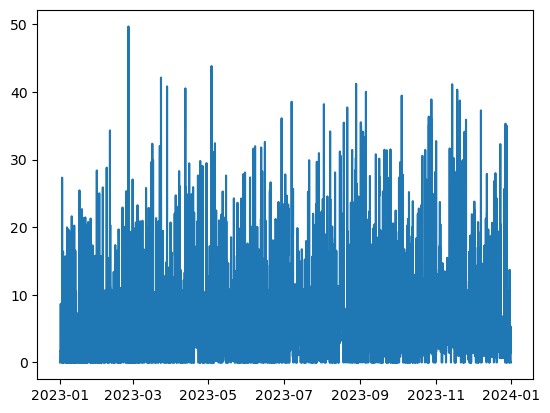

In [43]:
plt.plot(df_ev['Time'], df_ev['Total'])

In [44]:
df_ev = df.copy() # Good practice to avoid SettingWithCopy warnings

# Bring 'Time' back out of the index and into a standard column
df_ev = df_ev.reset_index()
df_ev


,index,Id,Start,End,MeterStart,MeterEnd,DurationTotal,MeterTotal,EVSEId,ChargePointLabel,RateSlug,TotalCosts,CostTotalGross,TotalAmountDuration,TotalAmountPower,TotalAmountOfLocalCurrency,CardId,EMPName
0,0,44950385,2023-01-01 12:57:34,2023-01-01 14:06:52,0,8070,4158,8070,FR*LDL*E00000149,LFR3591EVCP05,INTERN_550_COM186,1.530,1.530,0,1.530,1.530,Roaming,Chargemap SAS
1,1,44930833,2023-01-01 00:55:15,2023-01-01 19:47:40,0,31848,67945,31848,FR*LDL*E00000147,LFR3591EVCP04,INTERN_550_COM186,6.038,6.038,0,6.038,6.038,Roaming,IZIVIA
2,2,44991186,2023-01-02 07:01:55,2023-01-02 07:35:46,0,3910,2031,3910,FR*LDL*E00000150,LFR3591EVCP05,INTERN_550_COM186,0.741,0.741,0,0.741,0.741,Roaming,Chargemap SAS
3,3,44998697,2023-01-02 08:49:00,2023-01-02 09:08:30,0,2207,1170,2207,FR*LDL*E00000147,LFR3591EVCP04,INTERN_550_COM186,0.418,0.418,0,0.418,0.418,Roaming,Chargemap SAS
4,4,45050871,2023-01-02 16:28:04,2023-01-02 17:02:09,0,11230,2045,11230,FR*LDL*E00000150,LFR3591EVCP05,INTERN_550_COM186,2.129,2.129,0,2.129,2.129,Roaming,Threeforce B.V.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,2374,76335084,2023-12-30 20:20:11,2023-12-30 22:10:23,0,22684,6612,22684,FR*LDL*E00000143,LFR3591EVCP02,INTERN_550_COM268,5.100,5.100,0,5.100,5.100,Roaming,Chargemap SAS
2375,2375,76341850,2023-12-31 07:44:38,2023-12-31 08:17:38,0,2200,1980,2200,FR*LDL*E00000150,LFR3591EVCP05,INTERN_550_COM268,0.150,0.150,0,0.150,0.150,Roaming,Virtual Direct Payment Provider
2376,2376,76364498,2023-12-31 13:35:50,2023-12-31 14:26:12,0,1497,3022,1497,FR*LDL*E00000145,LFR3591EVCP03,INTERN_550_COM268,0.000,0.000,0,0.000,0.000,Roaming,Virtual Direct Payment Provider
2377,2377,76362008,2023-12-31 12:58:09,2023-12-31 17:07:59,0,9225,14990,9225,FR*LDL*E00000148,LFR3591EVCP04,INTERN_550_COM268,2.070,2.070,0,2.070,2.070,Roaming,Chargemap SAS


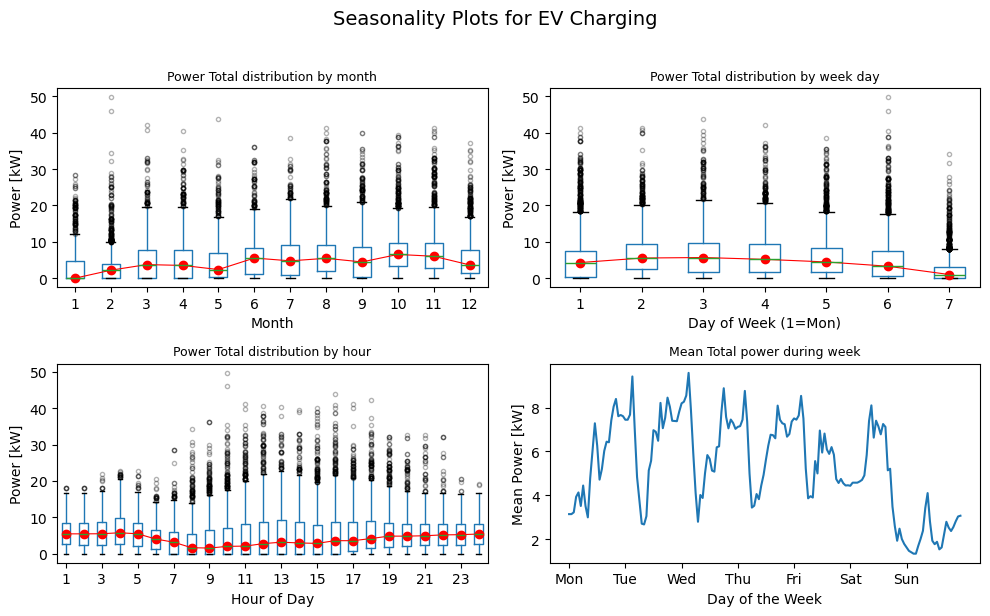

In [45]:
# Assuming df_ev is your dataframe from previous cells
df_ev = convert_for_EV(df)
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=False)
axs = axs.ravel()

# 1. Users distribution by month
df_ev['month'] = df_ev['Time'].dt.month  # Added .dt
df_ev.boxplot(column='Total', by='month', ax=axs[0], flierprops={'markersize': 3, 'alpha': 0.3})
df_ev.groupby('month')['Total'].median().plot(style='o-', linewidth=0.8, ax=axs[0], color='red')
axs[0].set_ylabel('Power [kW]') # Standardized label
axs[0].set_xlabel('Month')
axs[0].set_title('Power Total distribution by month', fontsize=9)

# 2. Users distribution by week day
df_ev['week_day'] = df_ev['Time'].dt.dayofweek + 1  # Added .dt and changed to dayofweek
df_ev.boxplot(column='Total', by='week_day', ax=axs[1], flierprops={'markersize': 3, 'alpha': 0.3})
df_ev.groupby('week_day')['Total'].median().plot(style='o-', linewidth=0.8, ax=axs[1], color='red')
axs[1].set_ylabel('Power [kW]')
axs[1].set_xlabel('Day of Week (1=Mon)')
axs[1].set_title('Power Total distribution by week day', fontsize=9)

# 3. Users distribution by the hour of the day
df_ev['hour_day'] = df_ev['Time'].dt.hour + 1  # Added .dt
df_ev.boxplot(column='Total', by='hour_day', ax=axs[2], flierprops={'markersize': 3, 'alpha': 0.3})
df_ev.groupby('hour_day')['Total'].median().plot(style='o-', linewidth=0.8, ax=axs[2], color='red')
axs[2].set_ylabel('Power [kW]')
axs[2].set_xlabel('Hour of Day')
axs[2].set_title('Power Total distribution by hour', fontsize=9)
axs[2].set_xticks(range(1, 25, 2))

# 4. Users distribution by week day and hour of the day
mean_day_hour = df_ev.groupby(["week_day", "hour_day"])["Total"].mean()
# Reset index to make plotting a continuous line easier
mean_day_hour.values 
axs[3].plot(mean_day_hour.values) # Plotting the raw values as a continuous line
axs[3].set(
    title       = "Mean Total power during week",
    xticks      = [i * 24 for i in range(7)],
    xticklabels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel      = "Day of the Week",
    ylabel      = "Mean Power [kW]" # Corrected label
)
axs[3].title.set_size(9)

# Clean up layout and titles
plt.suptitle("") # Clears the automatic pandas boxplot title
fig.suptitle("Seasonality Plots for EV Charging", fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig("seasonality_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

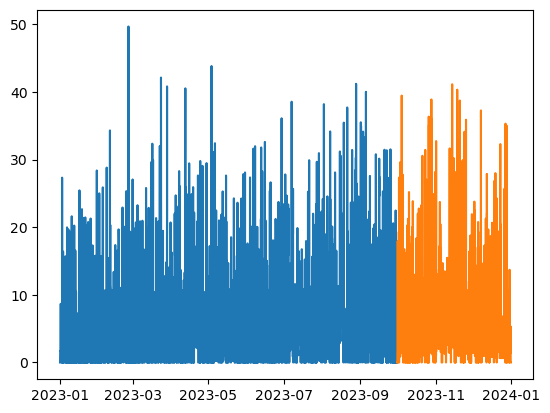

In [48]:
initial = df_ev.index[df_ev['Time'] == pd.Timestamp('2023-10-01 01:00:00', tz='Europe/Paris').tz_convert("UTC").tz_localize(None)][0]

df_train = df_ev.iloc[:initial]
df_test = df_ev.iloc[initial:]

plt.plot(df_train.Time.dt.tz_localize(None), df_train['Total'], label='Train')
plt.plot(df_test.Time.dt.tz_localize(None), df_test['Total'], label='Test')



In [49]:
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
days = 30
forecaster = ForecasterRecursive(
    estimator = XGBRegressor(n_estimators=460, learning_rate=0.01, random_state=42),
        # estimator = LGBMRegressor(random_state=15926, verbose=-1),
    # estimator= RandomForestRegressor(random_state=42),
    lags = int((60/15)*24*days), # use previous month
    window_features = RollingFeatures(stats=['max','std'], window_sizes=int((60/15)*24))
)

In [51]:
import joblib as jb
import json

output_dir = root_proj / "checkpoints" /"ev" / "2023" / "predictions" / "Ev_30d_xgb_2023"

if not (output_dir / "log.json").is_file(): # first train
    output_dir.mkdir(parents=True, exist_ok=True)
    # training
    forecaster.fit(y=df_train['Total'], store_in_sample_residuals=True)
    # residuals = forecaster.in_sample_residuals  # 查看训练残差
    # save model
    jb.dump(forecaster, output_dir/"model.joblib")
    # log
    log = {
        "metadata": {
            "description": "xgb 30d forecast for EV total power",
            "lags": int(forecaster.lags[-1]),
            "window_features": {
                "type": forecaster.window_features[0].__class__.__name__ ,
                "stats": forecaster.window_features[0].stats,
                "window_size": forecaster.window_features[0].window_sizes
            },
            "freq": "15min"
        },
        # "residuals": forecaster.in_sample_residuals
    }
    # save log
    with open(output_dir/"log.json", "w") as f:
        json.dump(log, f, indent=2)
    print("End of training")
else:
    # 加载模型 | load model
    forecaster = jb.load(output_dir/"model.joblib")
    # load log
    with open(output_dir/"log.json", "r") as f:
        log = json.load(f)
    print("Loaded")

End of training


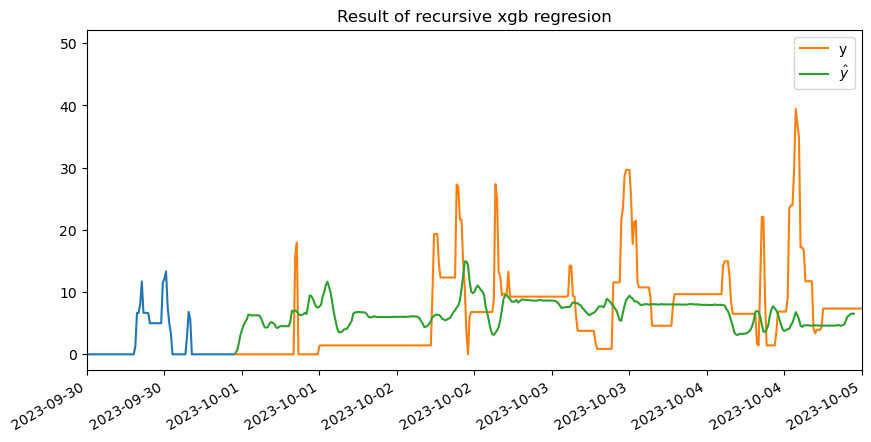

In [53]:
daysa = 96*4
yhat_test = forecaster.predict(steps=daysa)
# Save and display the plot
import matplotlib.ticker as ticker
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Result of recursive xgb regresion")
ax.plot(df_train['Time'],df_train['Total'])
# ax.plot(df_train['Time'],df_train['temp'])
ax.plot(df_test['Time'], df_test['Total'], label='y')
ax.plot(df_test['Time'][:daysa], yhat_test, label=r'$\hat{y}$')
# ax.plot(df_test['Time'][:daysa],df_test['temp'][:daysa], label='temp')
# ax.plot(df_after.Time.dt.tz_localize(None), df_after['PV'], label='After')

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

ax.set_xlim(pd.Timestamp('2023-09-30'), pd.Timestamp('2023-10-05'))

# optional: minor ticks every 6 hours
# ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))

ax.legend()

fig.autofmt_xdate() # for rotation
fig.savefig(output_dir / "prediction_test.png", dpi=300, bbox_inches='tight')
plt.show()